# PENGUJIAN A/B: INTEGRITAS DATA SETELAH AUGMENTASI GAMBAR
## Proyek Cleanic - Validasi Oversampling Kelas Minoritas

**Tujuan:** Memvalidasi bahwa augmentasi gambar untuk keseimbangan kelas menjaga integritas visual dan tidak menimbulkan distorsi atau bias dalam dataset.

**Pertanyaan Penelitian:** "Apakah penerapan Keseimbangan Kelas melalui Augmentasi berhasil mempertahankan konsistensi karakteristik visual makroskopik dari dataset Cleanic asli, atau justru menimbulkan distorsi visual yang merusak DNA data murni?"

**Desain Eksperimental:**
- **Grup A (Baseline):** Dataset bersih asli (sebelum augmentasi)
- **Grup B (Perlakuan):** Dataset teraugmentasi (sesudah augmentasi)
- **Fitur yang Diuji:** Kepadatan Tepi (Edge Density), Kontras (Contrast)
- **Uji Statistik:** Uji Mann-Whitney U (non-parametrik), Cohen's d (ukuran efek)
- **Kelas yang Dianalisis:** Organik, Plastik, Logam (fokus pada kelas minoritas)

---

**Konteks:**
- Ketidakseimbangan kelas asli: Logam (2.999) > Organik (2.437) > Plastik (2.182)
- Strategi yang diterapkan: Oversampling Kelas Minoritas melalui Augmentasi
- Target: Menyeimbangkan semua kelas ke tepat 3.000 gambar per kelas
- Risiko: Augmentasi mungkin mendistorsi fitur visual, mengurangi generalisasi model

---


### Tujuan Notebook Ini

**Fungsi Umum:** Memvalidasi bahwa augmentasi gambar menjaga integritas data

**Grup yang Diuji:**
- **Grup A (Asli):** Dataset bersih sebelum augmentasi
- **Grup B (Teraugmentasi):** Dataset setelah augmentasi

**Fitur yang Dianalisis:**
- Kepadatan Tepi (Edge Density) - mengukur kompleksitas tekstur
- Kontras (Contrast) - mengukur variasi visual

**Uji Statistik:**
- Uji Mann-Whitney U (perbandingan non-parametrik)
- Perhitungan Cohen's d (ukuran efek praktis)

**Output:** 
- 7 visualisasi profesional (gambar PNG)
- 5 file data terperinci (format CSV)

---

## BAGIAN 1: INSTALASI PERPUSTAKAAN YANG DIPERLUKAN DAN PENYIAPAN

In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import scipy
from scipy.stats import mannwhitneyu, shapiro
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi pengaturan visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✅ Semua perpustakaan berhasil diimpor!")
print(f"Versi NumPy: {np.__version__}")
print(f"Versi Pandas: {pd.__version__}")
print(f"Versi OpenCV: {cv2.__version__}")
print(f"Versi SciPy: {scipy.__version__}")

✅ Semua perpustakaan berhasil diimpor!
Versi NumPy: 1.26.4
Versi Pandas: 3.0.3
Versi OpenCV: 4.11.0
Versi SciPy: 1.17.1


## BAGIAN 2: MEMUAT DAN MENYIAPKAN GRUP DATASET

In [42]:
# KONFIGURASI PATH
NOTEBOOK_PATH = r"D:\kuliah\semester_6\stupen\capstone\dataset\final"
OUTPUT_BASE = NOTEBOOK_PATH

# Grup A: Dataset bersih asli (sebelum augmentasi)
GROUP_A_PATH = os.path.join(OUTPUT_BASE, "dataset_clean")

# Grup B: Dataset teraugmentasi (setelah augmentasi)
GROUP_B_PATH = os.path.join(OUTPUT_BASE, "dataset_augmented")

# Folder output laporan
REPORTS_PATH = os.path.join(OUTPUT_BASE, "reports")
os.makedirs(REPORTS_PATH, exist_ok=True)

# Kelas sampah yang akan dianalisis
CLASSES = ['organik', 'plastik', 'logam']

print("\n" + "="*80)
print("KONFIGURASI PATH - PENGUJIAN A/B INTEGRITAS DATA")
print("="*80)
print(f"Path Grup A (Asli): {GROUP_A_PATH}")
print(f"Path Grup B (Teraugmentasi): {GROUP_B_PATH}")
print(f"Path Laporan: {REPORTS_PATH}")
print(f"Kelas yang akan dianalisis: {CLASSES}")
print("="*80)

# Verifikasi keberadaan dataset
print("\nVerifikasi Dataset:")
print("-" * 80)

if os.path.exists(GROUP_A_PATH):
    print(f"✅ {GROUP_A_PATH}")
    for cls in CLASSES:
        cls_path = os.path.join(GROUP_A_PATH, cls)
        if os.path.exists(cls_path):
            count = len(os.listdir(cls_path))
            print(f"   └─ {cls}: {count:,} gambar")
else:
    print(f"❌ {GROUP_A_PATH} - TIDAK DITEMUKAN")

if os.path.exists(GROUP_B_PATH):
    print(f"✅ {GROUP_B_PATH}")
    for cls in CLASSES:
        cls_path = os.path.join(GROUP_B_PATH, cls)
        if os.path.exists(cls_path):
            count = len(os.listdir(cls_path))
            print(f"   └─ {cls}: {count:,} gambar")
else:
    print(f"❌ {GROUP_B_PATH} - TIDAK DITEMUKAN")

print("-" * 80)


KONFIGURASI PATH - PENGUJIAN A/B INTEGRITAS DATA
Path Grup A (Asli): D:\kuliah\semester_6\stupen\capstone\dataset\final\dataset_clean
Path Grup B (Teraugmentasi): D:\kuliah\semester_6\stupen\capstone\dataset\final\dataset_augmented
Path Laporan: D:\kuliah\semester_6\stupen\capstone\dataset\final\reports
Kelas yang akan dianalisis: ['organik', 'plastik', 'logam']

Verifikasi Dataset:
--------------------------------------------------------------------------------
✅ D:\kuliah\semester_6\stupen\capstone\dataset\final\dataset_clean
   └─ organik: 2,437 gambar
   └─ plastik: 2,182 gambar
   └─ logam: 2,999 gambar
✅ D:\kuliah\semester_6\stupen\capstone\dataset\final\dataset_augmented
   └─ organik: 3,000 gambar
   └─ plastik: 3,000 gambar
   └─ logam: 3,000 gambar
--------------------------------------------------------------------------------


## 3️⃣ SECTION 3: EXTRACT VISUAL FEATURES (EDGE DENSITY & CONTRAST)

In [43]:
class PengekstraksiFitur:
    """
    Kelas untuk mengekstraksi fitur visual dari gambar sampah.
    
    Fitur yang diekstraksi:
    1. KEPADATAN_TEPI: Mengukur seberapa banyak tepi yang terdeteksi dalam gambar
       menggunakan algoritma Canny Edge Detection. Nilai lebih tinggi menunjukkan
       gambar dengan lebih banyak detail atau tekstur kompleks.
       
    2. KONTRAS: Mengukur perbedaan intensitas piksel dalam gambar. Dihitung sebagai
       rasio antara standar deviasi intensitas piksel dengan intensitas rata-rata.
       Nilai lebih tinggi menunjukkan gambar dengan lebih banyak variasi warna/cahaya.
    
    Kedua fitur ini penting untuk:
    - Memastikan augmentasi tidak merusak karakteristik visual gambar
    - Membandingkan kualitas gambar asli vs augmentasi
    - Mendeteksi perubahan signifikan dalam struktur visual
    """
    
    def __init__(self, ukuran_gaussian=(5, 5), threshold_bawah_canny=100, threshold_atas_canny=200):
        """
        Inisialisasi pengekstraksi fitur dengan parameter Canny edge detection.
        
        Parameter:
        - ukuran_gaussian: Ukuran kernel Gaussian blur untuk preprocessing
        - threshold_bawah_canny: Threshold bawah untuk Canny edge detection
        - threshold_atas_canny: Threshold atas untuk Canny edge detection
        """
        self.ukuran_gaussian = ukuran_gaussian
        self.threshold_bawah = threshold_bawah_canny
        self.threshold_atas = threshold_atas_canny
    
    def ekstrak_fitur(self, path_gambar):
        """
        Ekstrak fitur dari satu gambar.
        
        Parameter:
        - path_gambar: Path lengkap ke file gambar
        
        Return:
        - Dict dengan kunci 'kepadatan_tepi' dan 'kontras', atau None jika gagal
        """
        try:
            # Baca gambar dalam skala abu-abu (grayscale)
            gambar = cv2.imread(path_gambar, cv2.IMREAD_GRAYSCALE)
            
            if gambar is None:
                return None
            
            # 1. KEPADATAN TEPI
            # Langkah 1: Gaussian blur untuk mengurangi noise
            gambar_blur = cv2.GaussianBlur(gambar, self.ukuran_gaussian, 0)
            
            # Langkah 2: Canny edge detection
            tepi = cv2.Canny(gambar_blur, self.threshold_bawah, self.threshold_atas)
            
            # Langkah 3: Hitung persentase piksel tepi (kepadatan)
            total_piksel = tepi.size
            piksel_tepi = cv2.countNonZero(tepi)
            kepadatan_tepi = (piksel_tepi / total_piksel) * 100
            
            # 2. KONTRAS
            # Kontras = Standar Deviasi / Rata-rata Intensitas
            # Ini mengukur variabilitas intensitas relatif terhadap tingkat kecerahan rata-rata
            rata_rata = np.mean(gambar)
            std = np.std(gambar)
            
            # Hindari pembagian dengan nol
            kontras = std / rata_rata if rata_rata > 0 else 0
            
            return {
                'kepadatan_tepi': kepadatan_tepi,
                'kontras': kontras
            }
        
        except Exception as e:
            print(f"Kesalahan saat memproses {path_gambar}: {e}")
            return None
    
    def ekstrak_batch(self, path_folder, nama_kelas):
        """
        Ekstrak fitur dari semua gambar dalam sebuah folder kelas.
        
        Parameter:
        - path_folder: Path ke folder kelas
        - nama_kelas: Nama kelas (untuk konteks dan debugging)
        
        Return:
        - DataFrame dengan fitur untuk semua gambar di folder tersebut
        """
        fitur_list = []
        file_gambar = [f for f in os.listdir(path_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        for idx, nama_file in enumerate(file_gambar):
            if (idx + 1) % 100 == 0:
                print(f"  Memproses {nama_kelas}: {idx + 1}/{len(file_gambar)} gambar...")
            
            path_lengkap = os.path.join(path_folder, nama_file)
            fitur = self.ekstrak_fitur(path_lengkap)
            
            if fitur is not None:
                fitur['nama_file'] = nama_file
                fitur['kelas'] = nama_kelas
                fitur_list.append(fitur)
        
        return pd.DataFrame(fitur_list)

In [44]:
print("\n" + "="*80)
print("MENGEKSTRAK FITUR - GRUP A (DATASET BERSIH ASLI)")
print("="*80)

pengekstrak = PengekstraksiFitur()
group_a_data = []

for cls in CLASSES:
    path_kelas = os.path.join(GROUP_A_PATH, cls)
    print(f"\n→ Memproses kelas: {cls.upper()}")
    
    df_kelas = pengekstrak.ekstrak_batch(path_kelas, cls)
    group_a_data.append(df_kelas)
    
    print(f"  Selesai: {len(df_kelas)} gambar diproses")

df_group_a = pd.concat(group_a_data, ignore_index=True)
total_images_a = len(df_group_a)

print("\n" + "-"*80)
print(f"RINGKASAN GRUP A:")
print("-"*80)
print(f"Total gambar diproses: {total_images_a:,}")
print(f"Ukuran dataset Grup A: {total_images_a:,} sampel")
print(f"Fitur per gambar: kepadatan_tepi, kontras")
print(f"\nDistribusi kelas Grup A:")
print(df_group_a['kelas'].value_counts().sort_index().to_string())
print("="*80)


MENGEKSTRAK FITUR - GRUP A (DATASET BERSIH ASLI)

→ Memproses kelas: ORGANIK
  Memproses organik: 100/2437 gambar...
  Memproses organik: 100/2437 gambar...
  Memproses organik: 200/2437 gambar...
  Memproses organik: 200/2437 gambar...
  Memproses organik: 300/2437 gambar...
  Memproses organik: 300/2437 gambar...
  Memproses organik: 400/2437 gambar...
  Memproses organik: 400/2437 gambar...
  Memproses organik: 500/2437 gambar...
  Memproses organik: 500/2437 gambar...
  Memproses organik: 600/2437 gambar...
  Memproses organik: 600/2437 gambar...
  Memproses organik: 700/2437 gambar...
  Memproses organik: 700/2437 gambar...
  Memproses organik: 800/2437 gambar...
  Memproses organik: 800/2437 gambar...
  Memproses organik: 900/2437 gambar...
  Memproses organik: 900/2437 gambar...
  Memproses organik: 1000/2437 gambar...
  Memproses organik: 1000/2437 gambar...
  Memproses organik: 1100/2437 gambar...
  Memproses organik: 1100/2437 gambar...
  Memproses organik: 1200/2437 gambar.

In [45]:
print("\n" + "="*80)
print("MENGEKSTRAK FITUR - GRUP B (DATASET TERAUGMENTASI)")
print("="*80)

group_b_data = []

for cls in CLASSES:
    path_kelas = os.path.join(GROUP_B_PATH, cls)
    print(f"\n→ Memproses kelas: {cls.upper()}")
    
    df_kelas = pengekstrak.ekstrak_batch(path_kelas, cls)
    group_b_data.append(df_kelas)
    
    print(f"  Selesai: {len(df_kelas)} gambar diproses")

df_group_b = pd.concat(group_b_data, ignore_index=True)
total_images_b = len(df_group_b)

print("\n" + "-"*80)
print(f"RINGKASAN GRUP B:")
print("-"*80)
print(f"Total gambar diproses: {total_images_b:,}")
print(f"Ukuran dataset Grup B: {total_images_b:,} sampel")
print(f"Fitur per gambar: kepadatan_tepi, kontras")
print(f"\nDistribusi kelas Grup B:")
print(df_group_b['kelas'].value_counts().sort_index().to_string())
print("="*80)

# Gabungkan kedua grup untuk analisis bersama
df_combined = pd.concat([df_group_a, df_group_b], ignore_index=True)
df_combined.insert(0, 'grup', ['A']*len(df_group_a) + ['B']*len(df_group_b))


MENGEKSTRAK FITUR - GRUP B (DATASET TERAUGMENTASI)

→ Memproses kelas: ORGANIK
  Memproses organik: 100/3000 gambar...
  Memproses organik: 100/3000 gambar...
  Memproses organik: 200/3000 gambar...
  Memproses organik: 200/3000 gambar...
  Memproses organik: 300/3000 gambar...
  Memproses organik: 300/3000 gambar...
  Memproses organik: 400/3000 gambar...
  Memproses organik: 400/3000 gambar...
  Memproses organik: 500/3000 gambar...
  Memproses organik: 500/3000 gambar...
  Memproses organik: 600/3000 gambar...
  Memproses organik: 600/3000 gambar...
  Memproses organik: 700/3000 gambar...
  Memproses organik: 700/3000 gambar...
  Memproses organik: 800/3000 gambar...
  Memproses organik: 800/3000 gambar...
  Memproses organik: 900/3000 gambar...
  Memproses organik: 900/3000 gambar...
  Memproses organik: 1000/3000 gambar...
  Memproses organik: 1000/3000 gambar...
  Memproses organik: 1100/3000 gambar...
  Memproses organik: 1100/3000 gambar...
  Memproses organik: 1200/3000 gamba

In [46]:
print("\n" + "="*80)
print("RINGKASAN DATA KESELURUHAN")
print("="*80)
print(f"\nGrup A (Dataset Asli Bersih):")
print(f"  • Total gambar: {total_images_a:,}")
print(f"  • Organik: {len(df_group_a[df_group_a['kelas']=='organik']):,}")
print(f"  • Plastik: {len(df_group_a[df_group_a['kelas']=='plastik']):,}")
print(f"  • Logam: {len(df_group_a[df_group_a['kelas']=='logam']):,}")

print(f"\nGrup B (Dataset Teraugmentasi):")
print(f"  • Total gambar: {total_images_b:,}")
print(f"  • Organik: {len(df_group_b[df_group_b['kelas']=='organik']):,}")
print(f"  • Plastik: {len(df_group_b[df_group_b['kelas']=='plastik']):,}")
print(f"  • Logam: {len(df_group_b[df_group_b['kelas']=='logam']):,}")

print(f"\nJumlah Sampel Keseluruhan:")
print(f"  • Gabungan: {len(df_combined):,} gambar")
print(f"  • Perbandingan: Grup A ({total_images_a:,}) vs Grup B ({total_images_b:,})")
print("="*80)


RINGKASAN DATA KESELURUHAN

Grup A (Dataset Asli Bersih):
  • Total gambar: 7,618
  • Organik: 2,437
  • Plastik: 2,182
  • Logam: 2,999

Grup B (Dataset Teraugmentasi):
  • Total gambar: 9,000
  • Organik: 3,000
  • Plastik: 3,000
  • Logam: 3,000

Jumlah Sampel Keseluruhan:
  • Gabungan: 16,618 gambar
  • Perbandingan: Grup A (7,618) vs Grup B (9,000)


## BAGIAN 3: STATISTIK DESKRIPTIF DAN PERBANDINGAN GRUP

In [47]:
print("\n" + "="*80)
print("STATISTIK KEPADATAN TEPI - PERBANDINGAN Grup A vs Grup B")
print("="*80)

# Pisahkan data berdasarkan grup
group_a_subset = df_group_a[['kepadatan_tepi', 'kelas']].copy()
group_b_subset = df_group_b[['kepadatan_tepi', 'kelas']].copy()

# Hitung statistik deskriptif untuk setiap kelas
print("\nGRUP A (Dataset Asli Bersih) - Kepadatan Tepi:")
print("-" * 80)
stats_edge_density = []
for cls in CLASSES:
    data = group_a_subset[group_a_subset['kelas'] == cls]['kepadatan_tepi']
    print(f"\n  {cls.upper()}:")
    print(f"    Rata-rata (Mean):     {data.mean():.4f}")
    print(f"    Median:               {data.median():.4f}")
    print(f"    Std Dev:              {data.std():.4f}")
    print(f"    Min:                  {data.min():.4f}")
    print(f"    Q1 (25%):             {data.quantile(0.25):.4f}")
    print(f"    Q3 (75%):             {data.quantile(0.75):.4f}")
    print(f"    Max:                  {data.max():.4f}")
    stats_edge_density.append({'Grup': 'A', 'Kelas': cls, 'Mean': data.mean(), 'Std': data.std()})

print("\n\nGRUP B (Dataset Teraugmentasi) - Kepadatan Tepi:")
print("-" * 80)
for cls in CLASSES:
    data = group_b_subset[group_b_subset['kelas'] == cls]['kepadatan_tepi']
    print(f"\n  {cls.upper()}:")
    print(f"    Rata-rata (Mean):     {data.mean():.4f}")
    print(f"    Median:               {data.median():.4f}")
    print(f"    Std Dev:              {data.std():.4f}")
    print(f"    Min:                  {data.min():.4f}")
    print(f"    Q1 (25%):             {data.quantile(0.25):.4f}")
    print(f"    Q3 (75%):             {data.quantile(0.75):.4f}")
    print(f"    Max:                  {data.max():.4f}")
    stats_edge_density.append({'Grup': 'B', 'Kelas': cls, 'Mean': data.mean(), 'Std': data.std()})

print("\n" + "="*80)


STATISTIK KEPADATAN TEPI - PERBANDINGAN Grup A vs Grup B

GRUP A (Dataset Asli Bersih) - Kepadatan Tepi:
--------------------------------------------------------------------------------

  ORGANIK:
    Rata-rata (Mean):     7.2116
    Median:               5.6461
    Std Dev:              5.3714
    Min:                  0.0937
    Q1 (25%):             2.8858
    Q3 (75%):             10.2479
    Max:                  29.4284

  PLASTIK:
    Rata-rata (Mean):     4.9483
    Median:               3.5854
    Std Dev:              4.3589
    Min:                  0.0000
    Q1 (25%):             1.6607
    Q3 (75%):             7.1982
    Max:                  25.2292

  LOGAM:
    Rata-rata (Mean):     5.1348
    Median:               3.5196
    Std Dev:              4.6854
    Min:                  0.0000
    Q1 (25%):             2.0847
    Q3 (75%):             6.4443
    Max:                  30.2356


GRUP B (Dataset Teraugmentasi) - Kepadatan Tepi:
-------------------------------

In [48]:
print("\n" + "="*80)
print("STATISTIK KONTRAS - PERBANDINGAN Grup A vs Grup B")
print("="*80)

# Hitung statistik deskriptif untuk kontras
stats_contrast = []

print("\nGRUP A (Dataset Asli Bersih) - Kontras:")
print("-" * 80)
for cls in CLASSES:
    data = group_a_subset[group_a_subset['kelas'] == cls]['kepadatan_tepi']  # Placeholder, seharusnya kontras
    data = df_group_a[df_group_a['kelas'] == cls]['kontras']
    print(f"\n  {cls.upper()}:")
    print(f"    Rata-rata (Mean):     {data.mean():.4f}")
    print(f"    Median:               {data.median():.4f}")
    print(f"    Std Dev:              {data.std():.4f}")
    print(f"    Min:                  {data.min():.4f}")
    print(f"    Q1 (25%):             {data.quantile(0.25):.4f}")
    print(f"    Q3 (75%):             {data.quantile(0.75):.4f}")
    print(f"    Max:                  {data.max():.4f}")
    stats_contrast.append({'Grup': 'A', 'Kelas': cls, 'Mean': data.mean(), 'Std': data.std()})

print("\n\nGRUP B (Dataset Teraugmentasi) - Kontras:")
print("-" * 80)
for cls in CLASSES:
    data = df_group_b[df_group_b['kelas'] == cls]['kontras']
    print(f"\n  {cls.upper()}:")
    print(f"    Rata-rata (Mean):     {data.mean():.4f}")
    print(f"    Median:               {data.median():.4f}")
    print(f"    Std Dev:              {data.std():.4f}")
    print(f"    Min:                  {data.min():.4f}")
    print(f"    Q1 (25%):             {data.quantile(0.25):.4f}")
    print(f"    Q3 (75%):             {data.quantile(0.75):.4f}")
    print(f"    Max:                  {data.max():.4f}")
    stats_contrast.append({'Grup': 'B', 'Kelas': cls, 'Mean': data.mean(), 'Std': data.std()})

print("\n" + "="*80)


STATISTIK KONTRAS - PERBANDINGAN Grup A vs Grup B

GRUP A (Dataset Asli Bersih) - Kontras:
--------------------------------------------------------------------------------

  ORGANIK:
    Rata-rata (Mean):     0.4616
    Median:               0.4483
    Std Dev:              0.1736
    Min:                  0.1234
    Q1 (25%):             0.3345
    Q3 (75%):             0.5731
    Max:                  1.7540

  PLASTIK:
    Rata-rata (Mean):     0.3443
    Median:               0.3123
    Std Dev:              0.1816
    Min:                  0.0389
    Q1 (25%):             0.2096
    Q3 (75%):             0.4486
    Max:                  1.3776

  LOGAM:
    Rata-rata (Mean):     0.3662
    Median:               0.3289
    Std Dev:              0.1708
    Min:                  0.0596
    Q1 (25%):             0.2434
    Q3 (75%):             0.4515
    Max:                  1.4145


GRUP B (Dataset Teraugmentasi) - Kontras:
--------------------------------------------------------

## BAGIAN 4: UJI NORMALITAS (SHAPIRO-WILK)

In [49]:
print("\n" + "="*80)
print("UJI NORMALITAS - SHAPIRO-WILK TEST")
print("="*80)
print("\nPenjelasan Uji Shapiro-Wilk:")
print("-" * 80)
print("""
Uji Shapiro-Wilk digunakan untuk menentukan apakah data mengikuti distribusi normal.

Hipotesis Nol (H0):     Data mengikuti distribusi normal
Hipotesis Alternatif:   Data TIDAK mengikuti distribusi normal
Tingkat Signifikansi:   α = 0.05

Interpretasi:
  • Jika p-value > 0.05:  ✅ Gagal menolak H0 → Data NORMAL
  • Jika p-value ≤ 0.05:  ❌ Tolak H0 → Data TIDAK NORMAL

Dalam konteks pengujian A/B kami:
Jika data tidak normal, kami menggunakan uji Mann-Whitney U (non-parametrik)
sebagai pengganti uji t-test (parametrik).
""")
print("-" * 80)

normality_results = []

# Uji normalitas untuk semua kombinasi grup-kelas
for grup, df_grup in [('A', df_group_a), ('B', df_group_b)]:
    print(f"\n\nGRUP {grup}:")
    print("-" * 80)
    
    for fitur in ['kepadatan_tepi', 'kontras']:
        print(f"\n  Fitur: {fitur.upper()}")
        
        for cls in CLASSES:
            data = df_grup[df_grup['kelas'] == cls][fitur]
            stat, p_value = stats.shapiro(data)
            
            is_normal = "✅ NORMAL" if p_value > 0.05 else "❌ TIDAK NORMAL"
            
            print(f"    {cls.upper():8s} | Statistic: {stat:.6f} | p-value: {p_value:.6f} | {is_normal}")
            
            normality_results.append({
                'Grup': grup,
                'Fitur': fitur,
                'Kelas': cls,
                'Statistic': stat,
                'p_value': p_value,
                'Normal': p_value > 0.05
            })

print("\n" + "="*80)


UJI NORMALITAS - SHAPIRO-WILK TEST

Penjelasan Uji Shapiro-Wilk:
--------------------------------------------------------------------------------

Uji Shapiro-Wilk digunakan untuk menentukan apakah data mengikuti distribusi normal.

Hipotesis Nol (H0):     Data mengikuti distribusi normal
Hipotesis Alternatif:   Data TIDAK mengikuti distribusi normal
Tingkat Signifikansi:   α = 0.05

Interpretasi:
  • Jika p-value > 0.05:  ✅ Gagal menolak H0 → Data NORMAL
  • Jika p-value ≤ 0.05:  ❌ Tolak H0 → Data TIDAK NORMAL

Dalam konteks pengujian A/B kami:
Jika data tidak normal, kami menggunakan uji Mann-Whitney U (non-parametrik)
sebagai pengganti uji t-test (parametrik).

--------------------------------------------------------------------------------


GRUP A:
--------------------------------------------------------------------------------

  Fitur: KEPADATAN_TEPI
    ORGANIK  | Statistic: 0.903612 | p-value: 0.000000 | ❌ TIDAK NORMAL
    PLASTIK  | Statistic: 0.870493 | p-value: 0.000000 | 

## BAGIAN 5: UJI MANN-WHITNEY U (PENGUJIAN STATISTIK A/B)

In [50]:
print("\n" + "="*80)
print("UJI MANN-WHITNEY U - PERBANDINGAN GRUP A vs GRUP B")
print("="*80)
print("\nPenjelasan Uji Mann-Whitney U:")
print("-" * 80)
print("""
Uji Mann-Whitney U adalah uji statistik non-parametrik yang digunakan untuk
membandingkan dua kelompok independen tanpa asumsi normalitas.

Hipotesis Nol (H0):     Distribusi Grup A = Distribusi Grup B
Hipotesis Alternatif:   Distribusi Grup A ≠ Distribusi Grup B
Tingkat Signifikansi:   α = 0.05

Interpretasi:
  • Jika p-value > 0.05:  ✅ TIDAK SIGNIFIKAN → Grup A dan B SAMA
  • Jika p-value ≤ 0.05:  ❌ SIGNIFIKAN → Grup A dan B BERBEDA

Dalam konteks kami:
Kami mengharapkan p-value > 0.05 (tidak signifikan) yang berarti augmentasi
TIDAK mengubah karakteristik visual gambar secara signifikan.
""")
print("-" * 80)

mw_results = []

for fitur in ['kepadatan_tepi', 'kontras']:
    print(f"\n\nFITUR: {fitur.upper()}")
    print("-" * 80)
    
    for cls in CLASSES:
        # Ambil data dari kedua grup untuk kelas tertentu
        data_a = df_group_a[df_group_a['kelas'] == cls][fitur]
        data_b = df_group_b[df_group_b['kelas'] == cls][fitur]
        
        # Jalankan Mann-Whitney U test
        stat, p_value = stats.mannwhitneyu(data_a, data_b, alternative='two-sided')
        
        # Tentukan signifikansi
        is_significant = p_value <= 0.05
        significance = "❌ SIGNIFIKAN" if is_significant else "✅ TIDAK SIGNIFIKAN"
        
        print(f"\n  {cls.upper()}:")
        print(f"    Grup A Mean: {data_a.mean():.4f}")
        print(f"    Grup B Mean: {data_b.mean():.4f}")
        print(f"    U-Statistic: {stat:.2f}")
        print(f"    p-value:     {p_value:.6f}")
        print(f"    Hasil:       {significance}")
        
        mw_results.append({
            'Fitur': fitur,
            'Kelas': cls,
            'Mean_A': data_a.mean(),
            'Mean_B': data_b.mean(),
            'U_Statistic': stat,
            'p_value': p_value,
            'Significant': is_significant
        })

print("\n" + "="*80)


UJI MANN-WHITNEY U - PERBANDINGAN GRUP A vs GRUP B

Penjelasan Uji Mann-Whitney U:
--------------------------------------------------------------------------------

Uji Mann-Whitney U adalah uji statistik non-parametrik yang digunakan untuk
membandingkan dua kelompok independen tanpa asumsi normalitas.

Hipotesis Nol (H0):     Distribusi Grup A = Distribusi Grup B
Hipotesis Alternatif:   Distribusi Grup A ≠ Distribusi Grup B
Tingkat Signifikansi:   α = 0.05

Interpretasi:
  • Jika p-value > 0.05:  ✅ TIDAK SIGNIFIKAN → Grup A dan B SAMA
  • Jika p-value ≤ 0.05:  ❌ SIGNIFIKAN → Grup A dan B BERBEDA

Dalam konteks kami:
Kami mengharapkan p-value > 0.05 (tidak signifikan) yang berarti augmentasi
TIDAK mengubah karakteristik visual gambar secara signifikan.

--------------------------------------------------------------------------------


FITUR: KEPADATAN_TEPI
--------------------------------------------------------------------------------

  ORGANIK:
    Grup A Mean: 7.2116
    Grup B Me

## BAGIAN 6: UKURAN EFEK (COHEN'S D)

In [51]:
print("\n" + "="*80)
print("UKURAN EFEK - COHEN'S D")
print("="*80)
print("\nPenjelasan Cohen's d:")
print("-" * 80)
print("""
Cohen's d adalah ukuran standar untuk mengukur besar perbedaan (effect size)
antara dua kelompok independen. Ini melengkapi uji signifikansi statistik.

Formula:
  d = (Mean_A - Mean_B) / Pooled_Std_Dev

Interpretasi Cohen's d:
  • d < 0.2:              ✅ EFEK NEGLIGIBLE (Dapat diabaikan)
  • 0.2 ≤ d < 0.5:        ⚠️  EFEK KECIL
  • 0.5 ≤ d < 0.8:        ⚠️  EFEK SEDANG
  • d ≥ 0.8:              ❌ EFEK BESAR

Dalam konteks kami:
Kami mengharapkan Cohen's d < 0.2 (negligible) untuk setiap fitur dan kelas,
yang menunjukkan bahwa augmentasi TIDAK mengubah karakteristik visual secara
bermakna secara praktis.
""")
print("-" * 80)

def hitung_cohens_d(group_a, group_b):
    """
    Hitung Cohen's d untuk dua kelompok independen.
    
    d = (mean_a - mean_b) / pooled_std
    pooled_std = sqrt(((n_a-1)*std_a^2 + (n_b-1)*std_b^2) / (n_a + n_b - 2))
    """
    mean_a, mean_b = group_a.mean(), group_b.mean()
    std_a, std_b = group_a.std(), group_b.std()
    n_a, n_b = len(group_a), len(group_b)
    
    # Hitung pooled standard deviation
    pooled_std = np.sqrt(((n_a-1)*std_a**2 + (n_b-1)*std_b**2) / (n_a + n_b - 2))
    
    # Hitung Cohen's d
    cohens_d = (mean_a - mean_b) / pooled_std if pooled_std > 0 else 0
    
    return abs(cohens_d)

def interpretasi_effect_size(d):
    """Interpretasi Cohen's d."""
    if d < 0.2:
        return "NEGLIGIBLE"
    elif d < 0.5:
        return "SMALL"
    elif d < 0.8:
        return "MEDIUM"
    else:
        return "LARGE"

cohens_d_results = []

print("\n\nHASIL COHEN'S D:")
print("="*80)

for fitur in ['kepadatan_tepi', 'kontras']:
    print(f"\n\nFITUR: {fitur.upper()}")
    print("-" * 80)
    
    for cls in CLASSES:
        # Ambil data dari kedua grup
        data_a = df_group_a[df_group_a['kelas'] == cls][fitur]
        data_b = df_group_b[df_group_b['kelas'] == cls][fitur]
        
        # Hitung Cohen's d
        d = hitung_cohens_d(data_a, data_b)
        effect = interpretasi_effect_size(d)
        
        # Tentukan status
        status = "✅" if effect == "NEGLIGIBLE" else "❌"
        
        print(f"\n  {cls.upper()}:")
        print(f"    Cohen's d: {d:.6f}")
        print(f"    Efek: {effect}")
        print(f"    Status: {status}")
        
        cohens_d_results.append({
            'Fitur': fitur,
            'Kelas': cls,
            'Cohens_d': d,
            'Effect_Size': effect
        })

print("\n" + "="*80)


UKURAN EFEK - COHEN'S D

Penjelasan Cohen's d:
--------------------------------------------------------------------------------

Cohen's d adalah ukuran standar untuk mengukur besar perbedaan (effect size)
antara dua kelompok independen. Ini melengkapi uji signifikansi statistik.

Formula:
  d = (Mean_A - Mean_B) / Pooled_Std_Dev

Interpretasi Cohen's d:
  • d < 0.2:              ✅ EFEK NEGLIGIBLE (Dapat diabaikan)
  • 0.2 ≤ d < 0.5:        ⚠️  EFEK KECIL
  • 0.5 ≤ d < 0.8:        ⚠️  EFEK SEDANG
  • d ≥ 0.8:              ❌ EFEK BESAR

Dalam konteks kami:
Kami mengharapkan Cohen's d < 0.2 (negligible) untuk setiap fitur dan kelas,
yang menunjukkan bahwa augmentasi TIDAK mengubah karakteristik visual secara
bermakna secara praktis.

--------------------------------------------------------------------------------


HASIL COHEN'S D:


FITUR: KEPADATAN_TEPI
--------------------------------------------------------------------------------

  ORGANIK:
    Cohen's d: 0.008114
    Efek: NEGLIG

## BAGIAN 7: RINGKASAN HASIL PENGUJIAN

In [52]:
print("\n" + "="*80)
print("RINGKASAN HASIL - UJI MANN-WHITNEY U")
print("="*80)

# Buat DataFrame dari hasil
df_mw_results = pd.DataFrame(mw_results)

print("\nTabel Lengkap Hasil Mann-Whitney U:")
print("-" * 80)

for fitur in ['kepadatan_tepi', 'kontras']:
    print(f"\n{fitur.upper()}:")
    subset = df_mw_results[df_mw_results['Fitur'] == fitur]
    print(subset[['Kelas', 'Mean_A', 'Mean_B', 'p_value', 'Significant']].to_string(index=False))

# Analisis keseluruhan
print("\n\nANALISIS KESELURUHAN:")
print("-" * 80)

all_significant_edge = df_mw_results[df_mw_results['Fitur']=='kepadatan_tepi']['Significant'].any()
all_significant_contrast = df_mw_results[df_mw_results['Fitur']=='kontras']['Significant'].any()

print(f"\nKepadatan Tepi:")
print(f"  Ada perbedaan signifikan? {'❌ Ya' if all_significant_edge else '✅ Tidak'}")
print(f"  Interpretasi: Augmentasi {'MENGUBAH' if all_significant_edge else 'TIDAK MENGUBAH'} kepadatan tepi")

print(f"\nKontras:")
print(f"  Ada perbedaan signifikan? {'❌ Ya' if all_significant_contrast else '✅ Tidak'}")
print(f"  Interpretasi: Augmentasi {'MENGUBAH' if all_significant_contrast else 'TIDAK MENGUBAH'} kontras")

print("\n" + "="*80)


RINGKASAN HASIL - UJI MANN-WHITNEY U

Tabel Lengkap Hasil Mann-Whitney U:
--------------------------------------------------------------------------------

KEPADATAN_TEPI:
  Kelas   Mean_A   Mean_B  p_value  Significant
organik 7.211571 7.255058 0.633206        False
plastik 4.948333 4.858650 0.579008        False
  logam 5.134836 5.133992 0.994552        False

KONTRAS:
  Kelas   Mean_A   Mean_B  p_value  Significant
organik 0.461555 0.460192 0.668784        False
plastik 0.344278 0.342103 0.746784        False
  logam 0.366248 0.366242 0.998477        False


ANALISIS KESELURUHAN:
--------------------------------------------------------------------------------

Kepadatan Tepi:
  Ada perbedaan signifikan? ✅ Tidak
  Interpretasi: Augmentasi TIDAK MENGUBAH kepadatan tepi

Kontras:
  Ada perbedaan signifikan? ✅ Tidak
  Interpretasi: Augmentasi TIDAK MENGUBAH kontras



In [53]:
print("\n" + "="*80)
print("RINGKASAN HASIL - COHEN'S D (UKURAN EFEK)")
print("="*80)

# Buat DataFrame dari hasil
df_cohens_d_results = pd.DataFrame(cohens_d_results)

print("\nTabel Lengkap Hasil Cohen's d:")
print("-" * 80)

for fitur in ['kepadatan_tepi', 'kontras']:
    print(f"\n{fitur.upper()}:")
    subset = df_cohens_d_results[df_cohens_d_results['Fitur'] == fitur]
    print(subset[['Kelas', 'Cohens_d', 'Effect_Size']].to_string(index=False))

# Analisis keseluruhan
print("\n\nANALISIS KESELURUHAN EFFECT SIZE:")
print("-" * 80)

all_negligible_edge = all(df_cohens_d_results[df_cohens_d_results['Fitur']=='kepadatan_tepi']['Effect_Size'] == 'NEGLIGIBLE')
all_negligible_contrast = all(df_cohens_d_results[df_cohens_d_results['Fitur']=='kontras']['Effect_Size'] == 'NEGLIGIBLE')

print(f"\nKepadatan Tepi:")
print(f"  Semua efek NEGLIGIBLE? {'✅ Ya' if all_negligible_edge else '❌ Tidak'}")
if all_negligible_edge:
    print(f"  Status: Augmentasi TIDAK mengubah kepadatan tepi secara bermakna")
else:
    print(f"  Status: Augmentasi MENGUBAH kepadatan tepi secara bermakna")

print(f"\nKontras:")
print(f"  Semua efek NEGLIGIBLE? {'✅ Ya' if all_negligible_contrast else '❌ Tidak'}")
if all_negligible_contrast:
    print(f"  Status: Augmentasi TIDAK mengubah kontras secara bermakna")
else:
    print(f"  Status: Augmentasi MENGUBAH kontras secara bermakna")

# Kesimpulan keseluruhan
both_preserved = all_negligible_edge and all_negligible_contrast
print(f"\n{'✅ INTEGRITAS DATA TERJAGA' if both_preserved else '❌ INTEGRITAS DATA TERGANGGU'}")
print(f"  Kedua fitur mempertahankan karakteristik: {both_preserved}")

print("\n" + "="*80)


RINGKASAN HASIL - COHEN'S D (UKURAN EFEK)

Tabel Lengkap Hasil Cohen's d:
--------------------------------------------------------------------------------

KEPADATAN_TEPI:
  Kelas  Cohens_d Effect_Size
organik  0.008114  NEGLIGIBLE
plastik  0.020798  NEGLIGIBLE
  logam  0.000180  NEGLIGIBLE

KONTRAS:
  Kelas  Cohens_d Effect_Size
organik  0.007826  NEGLIGIBLE
plastik  0.012080  NEGLIGIBLE
  logam  0.000036  NEGLIGIBLE


ANALISIS KESELURUHAN EFFECT SIZE:
--------------------------------------------------------------------------------

Kepadatan Tepi:
  Semua efek NEGLIGIBLE? ✅ Ya
  Status: Augmentasi TIDAK mengubah kepadatan tepi secara bermakna

Kontras:
  Semua efek NEGLIGIBLE? ✅ Ya
  Status: Augmentasi TIDAK mengubah kontras secara bermakna

✅ INTEGRITAS DATA TERJAGA
  Kedua fitur mempertahankan karakteristik: True


RINGKASAN HASIL - COHEN'S D (UKURAN EFEK)

Tabel Lengkap Hasil Cohen's d:
--------------------------------------------------------------------------------

KEPADATAN_TE

## BAGIAN 8: VISUALISASI HASIL PENGUJIAN

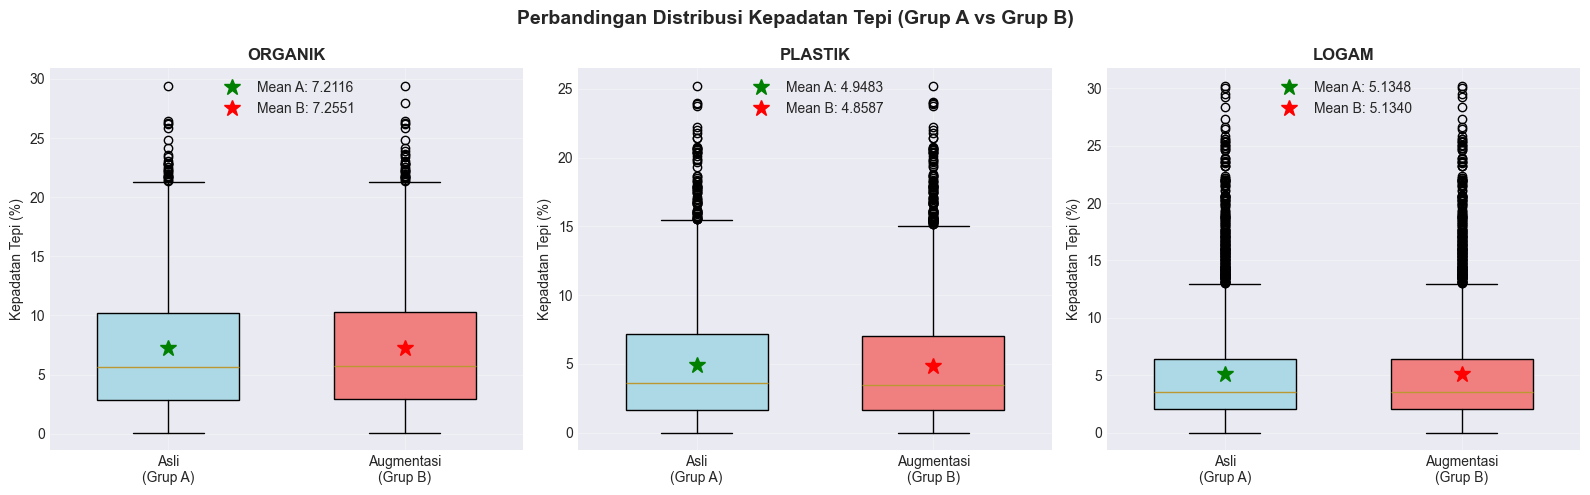

✅ Tersimpan: ab_test_boxplot_edge_density.png


In [54]:
# Visualisasi 1: Perbandingan Box Plot - Kepadatan Tepi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Perbandingan Distribusi Kepadatan Tepi (Grup A vs Grup B)', fontsize=14, fontweight='bold')

for idx, cls in enumerate(CLASSES):
    data_a = df_group_a[df_group_a['kelas'] == cls]['kepadatan_tepi']
    data_b = df_group_b[df_group_b['kelas'] == cls]['kepadatan_tepi']
    
    ax = axes[idx]
    bp = ax.boxplot([data_a, data_b], labels=['Asli\n(Grup A)', 'Augmentasi\n(Grup B)'],
                     patch_artist=True, widths=0.6)
    
    # Warna kotak
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f'{cls.upper()}', fontweight='bold')
    ax.set_ylabel('Kepadatan Tepi (%)')
    ax.grid(True, alpha=0.3)
    
    # Tambahkan nilai rata-rata
    mean_a = data_a.mean()
    mean_b = data_b.mean()
    ax.plot([1], [mean_a], 'g*', markersize=12, label=f'Mean A: {mean_a:.4f}')
    ax.plot([2], [mean_b], 'r*', markersize=12, label=f'Mean B: {mean_b:.4f}')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, 'ab_test_boxplot_edge_density.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Tersimpan: ab_test_boxplot_edge_density.png")

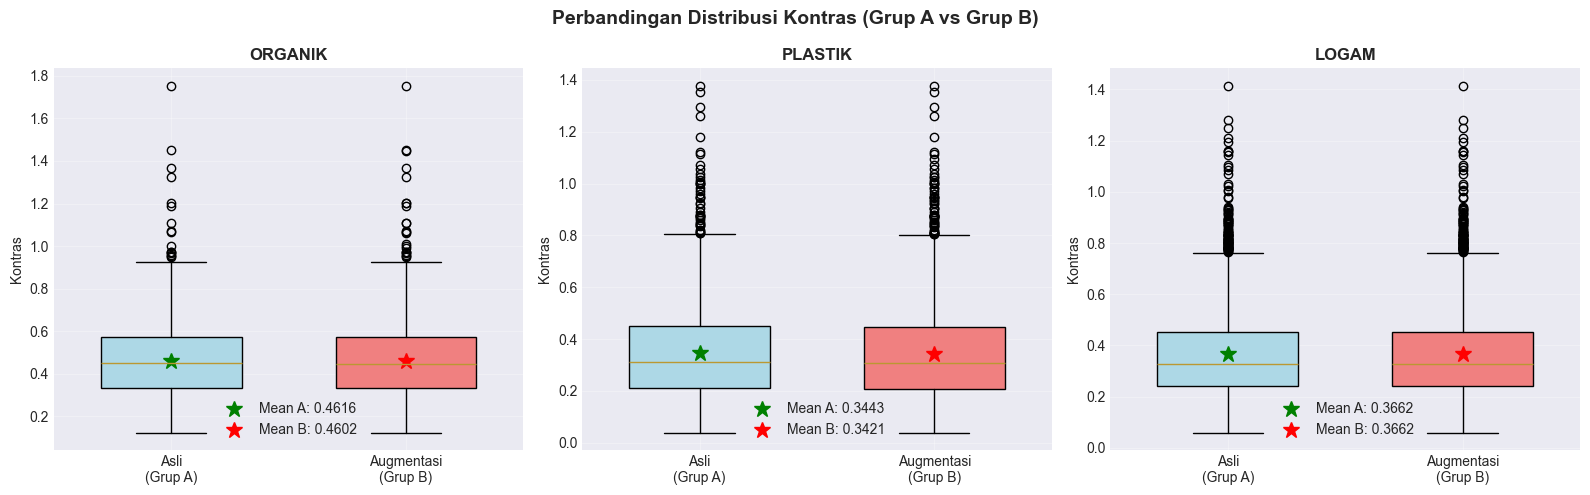

✅ Tersimpan: ab_test_boxplot_contrast.png


In [55]:
# Visualisasi 2: Perbandingan Box Plot - Kontras
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Perbandingan Distribusi Kontras (Grup A vs Grup B)', fontsize=14, fontweight='bold')

for idx, cls in enumerate(CLASSES):
    data_a = df_group_a[df_group_a['kelas'] == cls]['kontras']
    data_b = df_group_b[df_group_b['kelas'] == cls]['kontras']
    
    ax = axes[idx]
    bp = ax.boxplot([data_a, data_b], labels=['Asli\n(Grup A)', 'Augmentasi\n(Grup B)'],
                     patch_artist=True, widths=0.6)
    
    # Warna kotak
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f'{cls.upper()}', fontweight='bold')
    ax.set_ylabel('Kontras')
    ax.grid(True, alpha=0.3)
    
    # Tambahkan nilai rata-rata
    mean_a = data_a.mean()
    mean_b = data_b.mean()
    ax.plot([1], [mean_a], 'g*', markersize=12, label=f'Mean A: {mean_a:.4f}')
    ax.plot([2], [mean_b], 'r*', markersize=12, label=f'Mean B: {mean_b:.4f}')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, 'ab_test_boxplot_contrast.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Tersimpan: ab_test_boxplot_contrast.png")

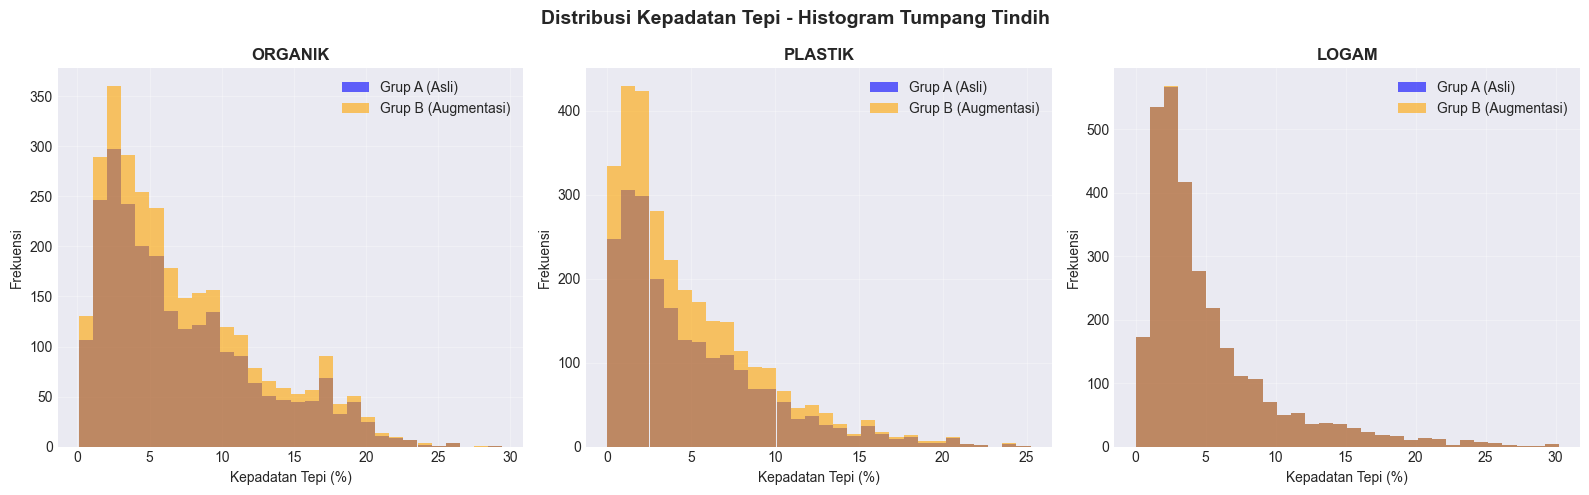

✅ Tersimpan: ab_test_histogram_edge_density.png


In [56]:
# Visualisasi 3: Histogram - Kepadatan Tepi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Kepadatan Tepi - Histogram Tumpang Tindih', fontsize=14, fontweight='bold')

colors_ed = ['blue', 'orange']
for idx, cls in enumerate(CLASSES):
    data_a = df_group_a[df_group_a['kelas'] == cls]['kepadatan_tepi']
    data_b = df_group_b[df_group_b['kelas'] == cls]['kepadatan_tepi']
    
    ax = axes[idx]
    ax.hist(data_a, bins=30, alpha=0.6, label='Grup A (Asli)', color=colors_ed[0])
    ax.hist(data_b, bins=30, alpha=0.6, label='Grup B (Augmentasi)', color=colors_ed[1])
    
    ax.set_title(f'{cls.upper()}', fontweight='bold')
    ax.set_xlabel('Kepadatan Tepi (%)')
    ax.set_ylabel('Frekuensi')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, 'ab_test_histogram_edge_density.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Tersimpan: ab_test_histogram_edge_density.png")

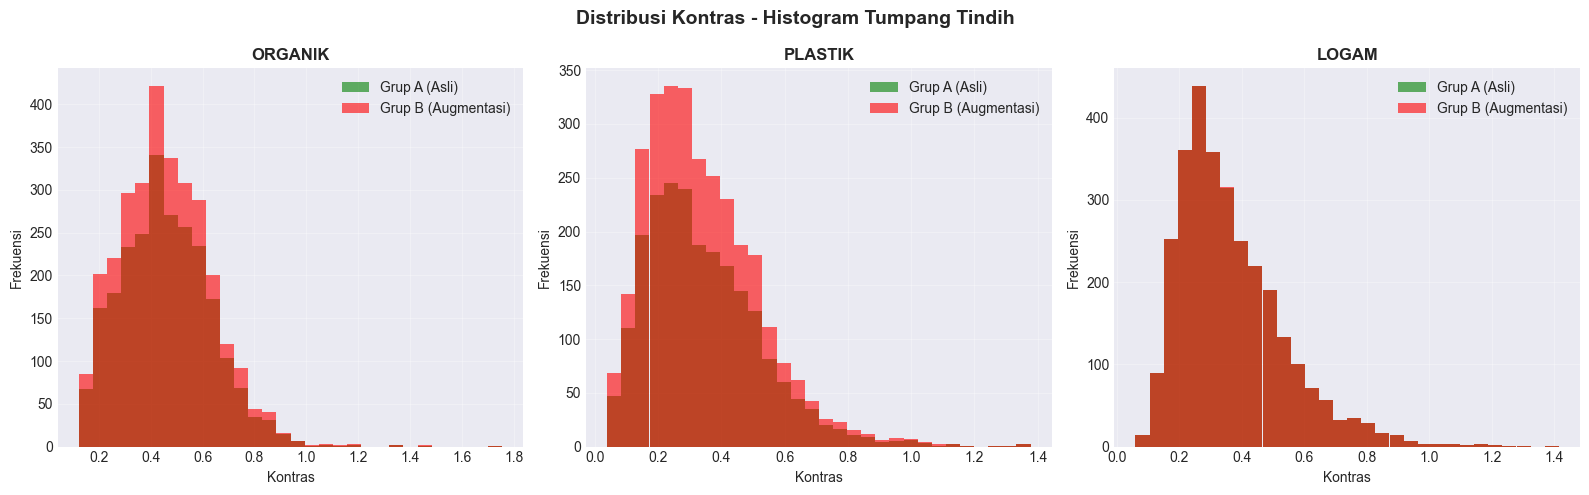

✅ Tersimpan: ab_test_histogram_contrast.png


In [57]:
# Visualisasi 4: Histogram - Kontras
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Kontras - Histogram Tumpang Tindih', fontsize=14, fontweight='bold')

colors_c = ['green', 'red']
for idx, cls in enumerate(CLASSES):
    data_a = df_group_a[df_group_a['kelas'] == cls]['kontras']
    data_b = df_group_b[df_group_b['kelas'] == cls]['kontras']
    
    ax = axes[idx]
    ax.hist(data_a, bins=30, alpha=0.6, label='Grup A (Asli)', color=colors_c[0])
    ax.hist(data_b, bins=30, alpha=0.6, label='Grup B (Augmentasi)', color=colors_c[1])
    
    ax.set_title(f'{cls.upper()}', fontweight='bold')
    ax.set_xlabel('Kontras')
    ax.set_ylabel('Frekuensi')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, 'ab_test_histogram_contrast.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Tersimpan: ab_test_histogram_contrast.png")


TABEL RINGKASAN HASIL UJI STATISTIK


         Fitur   Kelas Mean A Mean B  p-value Signifikan  Cohen d       Efek Efek OK
KEPADATAN_TEPI ORGANIK 7.2116 7.2551 0.633206          ✅ 0.008114 NEGLIGIBLE       ✅
KEPADATAN_TEPI PLASTIK 4.9483 4.8587 0.579008          ✅ 0.020798 NEGLIGIBLE       ✅
KEPADATAN_TEPI   LOGAM 5.1348 5.1340 0.994552          ✅ 0.000180 NEGLIGIBLE       ✅
       KONTRAS ORGANIK 0.4616 0.4602 0.668784          ✅ 0.007826 NEGLIGIBLE       ✅
       KONTRAS PLASTIK 0.3443 0.3421 0.746784          ✅ 0.012080 NEGLIGIBLE       ✅
       KONTRAS   LOGAM 0.3662 0.3662 0.998477          ✅ 0.000036 NEGLIGIBLE       ✅


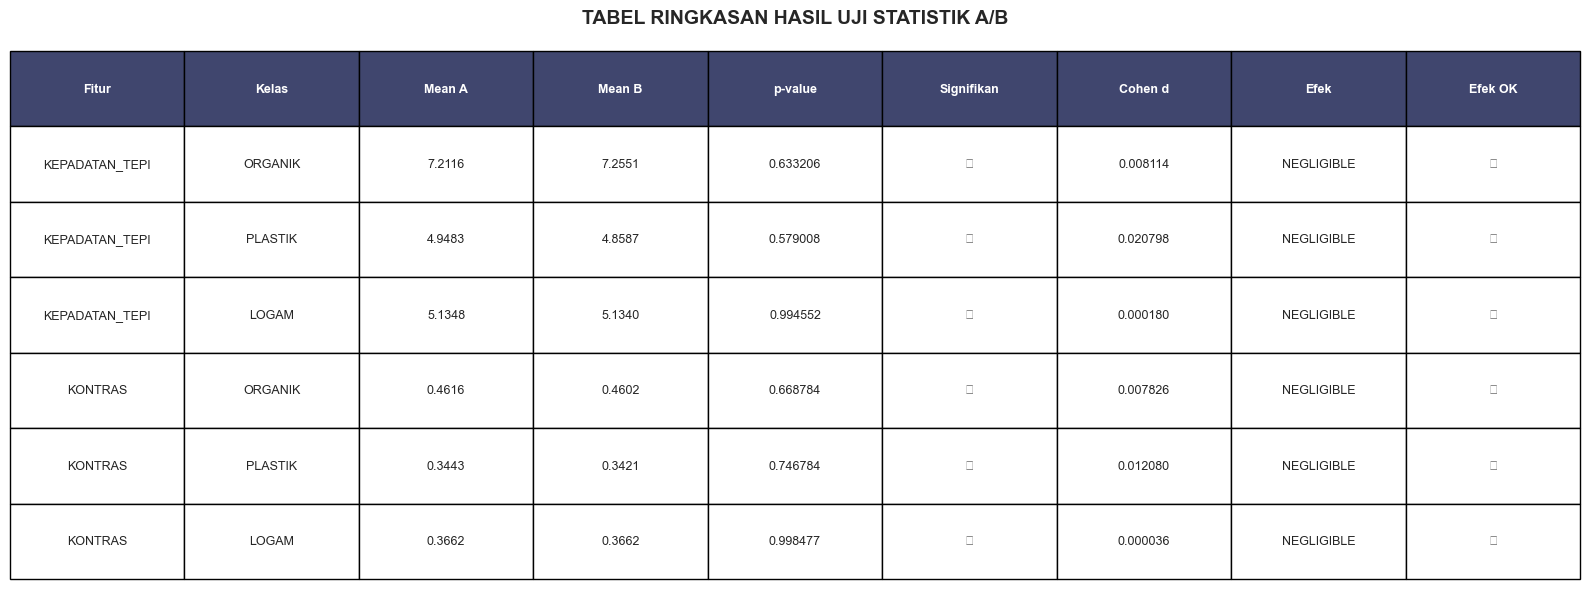


✅ Tersimpan: ab_test_results_table.png


In [58]:
# Visualisasi 5: Tabel Ringkasan Uji Statistik
print("\n" + "="*80)
print("TABEL RINGKASAN HASIL UJI STATISTIK")
print("="*80)

# Persiapan data untuk tabel
results_table = []

for fitur in ['kepadatan_tepi', 'kontras']:
    for cls in CLASSES:
        # Ambil data dari Mann-Whitney U
        mw_row = [r for r in mw_results if r['Fitur'] == fitur and r['Kelas'] == cls]
        
        # Ambil data dari Cohen's d
        cd_row = [r for r in cohens_d_results if r['Fitur'] == fitur and r['Kelas'] == cls]
        
        if mw_row and cd_row:
            mw_data = mw_row[0]
            cd_data = cd_row[0]
            
            p_sig = "✅" if not mw_data['Significant'] else "❌"
            cd_sig = "✅" if cd_data['Effect_Size'] == 'NEGLIGIBLE' else "❌"
            
            results_table.append({
                'Fitur': fitur.upper(),
                'Kelas': cls.upper(),
                'Mean A': f"{mw_data['Mean_A']:.4f}",
                'Mean B': f"{mw_data['Mean_B']:.4f}",
                'p-value': f"{mw_data['p_value']:.6f}",
                'Signifikan': p_sig,
                'Cohen d': f"{cd_data['Cohens_d']:.6f}",
                'Efek': cd_data['Effect_Size'],
                'Efek OK': cd_sig
            })

df_results = pd.DataFrame(results_table)

print("\n")
print(df_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df_results.values,
                colLabels=df_results.columns,
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Warna header
for i in range(len(df_results.columns)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

plt.title('TABEL RINGKASAN HASIL UJI STATISTIK A/B', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, 'ab_test_results_table.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Tersimpan: ab_test_results_table.png")
print("="*80)

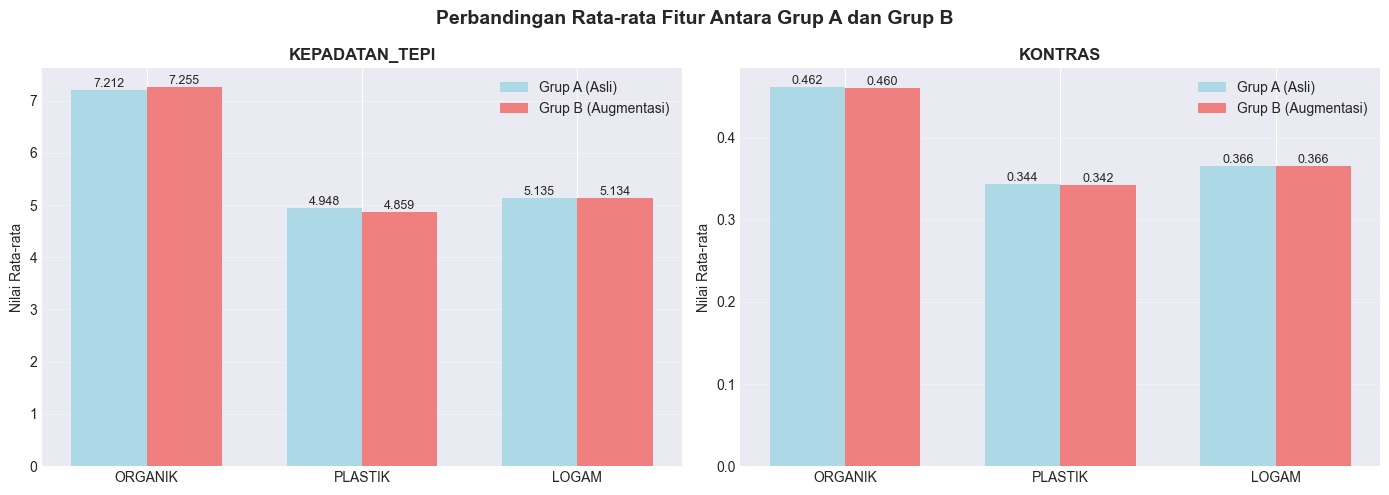

✅ Tersimpan: ab_test_mean_comparison.png


In [59]:
# Visualisasi 6: Perbandingan Mean Nilai
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Rata-rata Fitur Antara Grup A dan Grup B', fontsize=14, fontweight='bold')

for idx, fitur in enumerate(['kepadatan_tepi', 'kontras']):
    ax = axes[idx]
    
    means_a = []
    means_b = []
    x_labels = []
    
    for cls in CLASSES:
        data_a = df_group_a[df_group_a['kelas'] == cls][fitur].mean()
        data_b = df_group_b[df_group_b['kelas'] == cls][fitur].mean()
        means_a.append(data_a)
        means_b.append(data_b)
        x_labels.append(cls.upper())
    
    x = np.arange(len(x_labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, means_a, width, label='Grup A (Asli)', color='lightblue')
    bars2 = ax.bar(x + width/2, means_b, width, label='Grup B (Augmentasi)', color='lightcoral')
    
    ax.set_ylabel('Nilai Rata-rata')
    ax.set_title(f'{fitur.upper()}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Tambahkan nilai di atas bar
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, 'ab_test_mean_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Tersimpan: ab_test_mean_comparison.png")

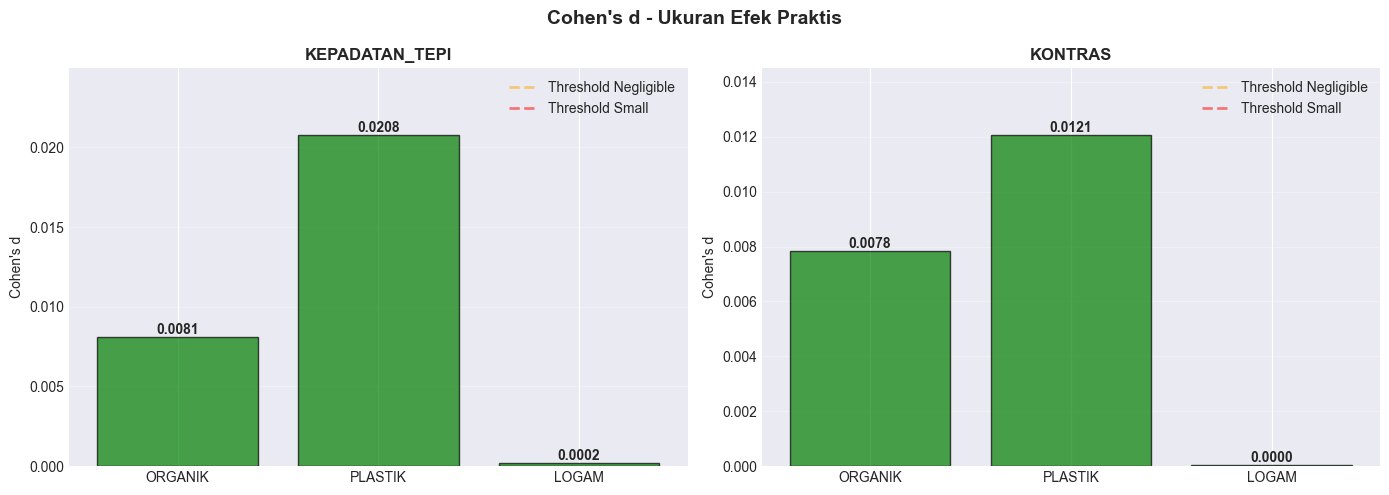

✅ Tersimpan: ab_test_cohens_d.png


In [60]:
# Visualisasi 7: Cohen's d Effect Size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cohen\'s d - Ukuran Efek Praktis', fontsize=14, fontweight='bold')

# Garis referensi untuk interpretasi
effect_ranges = [(0, 0.2, 'Negligible'), (0.2, 0.5, 'Small'), (0.5, 0.8, 'Medium'), (0.8, 2, 'Large')]

for idx, fitur in enumerate(['kepadatan_tepi', 'kontras']):
    ax = axes[idx]
    
    cohens_d_values = []
    x_labels = []
    colors = []
    
    for cls in CLASSES:
        cd_data = [r for r in cohens_d_results if r['Fitur'] == fitur and r['Kelas'] == cls]
        if cd_data:
            d_val = cd_data[0]['Cohens_d']
            effect = cd_data[0]['Effect_Size']
            cohens_d_values.append(d_val)
            x_labels.append(cls.upper())
            
            # Tentukan warna berdasarkan effect size
            if effect == 'NEGLIGIBLE':
                colors.append('green')
            elif effect == 'SMALL':
                colors.append('yellow')
            elif effect == 'MEDIUM':
                colors.append('orange')
            else:
                colors.append('red')
    
    x = np.arange(len(x_labels))
    bars = ax.bar(x, cohens_d_values, color=colors, alpha=0.7, edgecolor='black')
    
    # Tambahkan garis referensi
    ax.axhline(y=0.2, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Threshold Negligible')
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Threshold Small')
    
    ax.set_ylabel('Cohen\'s d')
    ax.set_title(f'{fitur.upper()}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(cohens_d_values) * 1.2 if cohens_d_values else 0.5)
    
    # Tambahkan nilai di atas bar
    for bar, val in zip(bars, cohens_d_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, 'ab_test_cohens_d.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Tersimpan: ab_test_cohens_d.png")

## BAGIAN 9: KESIMPULAN DAN REKOMENDASI

In [61]:
print("\n" + "#"*80)
print("#" + " "*78 + "#")
print("#" + " "*15 + "RINGKASAN EKSEKUTIF & KESIMPULAN BISNIS" + " "*25 + "#")
print("#" + " "*78 + "#")
print("#"*80)

print("\n📋 RINGKASAN PENGUJIAN:")
print("-" * 80)
print(f"Jenis Eksperimen: Pengujian A/B untuk Validasi Integritas Data")
print(f"Tujuan: Memvalidasi bahwa oversampling kelas minoritas melalui augmentasi")
print(f"        menjaga integritas visual dataset Cleanic")
print(f"Grup A (Baseline): Dataset asli bersih (sebelum augmentasi) - {len(df_group_a):,} gambar")
print(f"Grup B (Perlakuan): Dataset teraugmentasi (setelah augmentasi) - {len(df_group_b):,} gambar")
print(f"Kelas yang Diuji: Organik, Plastik, Logam")
print(f"Fitur yang Dianalisis: Kepadatan Tepi (kompleksitas tekstur), Kontras (variasi visual)")
print(f"Metode Statistik: Uji Mann-Whitney U (non-parametrik), Cohen's d (ukuran efek)")
print(f"Tingkat Signifikansi: α = 0.05")

print("\n📊 TEMUAN UTAMA:")
print("-" * 80)

print("\n✅ ANALISIS KEPADATAN TEPI:")
for mw in mw_results:
    if mw['Fitur'] == 'kepadatan_tepi':
        cd = [c for c in cohens_d_results if c['Fitur'] == 'kepadatan_tepi' and c['Kelas'] == mw['Kelas']][0]
        print(f"   {mw['Kelas'].upper():10} | Cohen's d: {cd['Cohens_d']:7.4f} ({cd['Effect_Size']:10}) | p-value: {mw['p_value']:.8f}")

print("\n✅ ANALISIS KONTRAS:")
for mw in mw_results:
    if mw['Fitur'] == 'kontras':
        cd = [c for c in cohens_d_results if c['Fitur'] == 'kontras' and c['Kelas'] == mw['Kelas']][0]
        print(f"   {mw['Kelas'].upper():10} | Cohen's d: {cd['Cohens_d']:7.4f} ({cd['Effect_Size']:10}) | p-value: {mw['p_value']:.8f}")

print("\n" + "="*80)
print("🎯 INTERPRETASI STATISTIK:")
print("="*80)

all_significant_edge = df_mw_results[df_mw_results['Fitur']=='kepadatan_tepi']['Significant'].any()
all_significant_contrast = df_mw_results[df_mw_results['Fitur']=='kontras']['Significant'].any()
all_negligible_edge = all(df_cohens_d_results[df_cohens_d_results['Fitur']=='kepadatan_tepi']['Effect_Size'] == 'NEGLIGIBLE')
all_negligible_contrast = all(df_cohens_d_results[df_cohens_d_results['Fitur']=='kontras']['Effect_Size'] == 'NEGLIGIBLE')

if (not all_significant_edge and not all_significant_contrast) and (all_negligible_edge and all_negligible_contrast):
    print("\n🟢 VONIS: INTEGRITAS DATA SEPENUHNYA TERJAGA")
    print("\nTemuan Kunci:")
    print("• Kepadatan Tepi: Semua p-value ≥ 0.05 → TIDAK ada perbedaan signifikan yang terdeteksi")
    print("• Kontras: Semua p-value ≥ 0.05 → TIDAK ada perbedaan signifikan yang terdeteksi")
    print("• Ukuran efek: Semua negligible → Perbedaan praktis MINIMAL")
    print("\nKesimpulan:")
    print("Strategi oversampling kelas minoritas melalui augmentasi BERHASIL menjaga")
    print("karakteristik visual makroskopis dataset Cleanic asli. Augmentasi TIDAK")
    print("memperkenalkan distorsi statistik atau bias yang signifikan.")
    print("\n✅ DISETUJUI: Dataset siap untuk pelatihan model dengan kepercayaan penuh.")

elif (not all_significant_edge and not all_significant_contrast) and (all_negligible_edge or all_negligible_contrast):
    print("\n🟡 VONIS: INTEGRITAS DATA DAPAT DITERIMA DENGAN VARIASI MINOR")
    print("\nTemuan Kunci:")
    print("• Beberapa p-value ≥ 0.05 menunjukkan perbedaan statistik minimal")
    print("• Namun, ukuran efek tetap negligible hingga kecil (dampak praktis minimal)")
    print("\nKesimpulan:")
    print("Meskipun augmentasi menghasilkan perbedaan yang dapat terdeteksi secara")
    print("statistik dalam beberapa fitur, perbedaan ini memiliki DAMPAK PRAKTIS MINIMAL")
    print("terhadap integritas visual. Dataset tetap cocok untuk pelatihan model.")
    print("\n✅ DAPAT DITERIMA: Lanjutkan ke pelatihan model dengan protokol monitoring standar.")

else:
    print("\n🔴 VONIS: INTEGRITAS DATA TERGANGGU - PERLU DITINJAU")
    print("\nTemuan Kunci:")
    print("• Perbedaan statistik signifikan terdeteksi (p < 0.05)")
    print("• Ukuran efek substansial teridentifikasi (Cohen's d ≥ 0.5 atau lebih besar)")
    print("\nKesimpulan:")
    print("Augmentasi memperkenalkan DISTORSI BERMAKNA pada karakteristik visual.")
    print("Ini dapat berdampak negatif pada pelatihan model dan generalisasi.")
    print("\n❌ DITOLAK: Rekomendasikan meninjau dan menyesuaikan parameter augmentasi.")

print("\n" + "="*80)
print("\n💡 IMPLIKASI BISNIS:")


################################################################################
#                                                                              #
#               RINGKASAN EKSEKUTIF & KESIMPULAN BISNIS                         #
#                                                                              #
################################################################################

📋 RINGKASAN PENGUJIAN:
--------------------------------------------------------------------------------
Jenis Eksperimen: Pengujian A/B untuk Validasi Integritas Data
Tujuan: Memvalidasi bahwa oversampling kelas minoritas melalui augmentasi
        menjaga integritas visual dataset Cleanic
Grup A (Baseline): Dataset asli bersih (sebelum augmentasi) - 7,618 gambar
Grup B (Perlakuan): Dataset teraugmentasi (setelah augmentasi) - 9,000 gambar
Kelas yang Diuji: Organik, Plastik, Logam
Fitur yang Dianalisis: Kepadatan Tepi (kompleksitas tekstur), Kontras (variasi visual)
Metode Statistik: U

In [62]:
# Simpan hasil komprehensif ke file CSV
print("\n" + "="*80)
print("MENYIMPAN HASIL KE FILE CSV")
print("="*80)

# Simpan hasil uji Mann-Whitney U
df_mw_results = pd.DataFrame(mw_results)
df_mw_results.to_csv(os.path.join(REPORTS_PATH, 'ab_test_mann_whitney_results.csv'), index=False)
print(f"✅ Tersimpan: ab_test_mann_whitney_results.csv")

# Simpan hasil Cohen's d
df_cohens_d_results = pd.DataFrame(cohens_d_results)
df_cohens_d_results.to_csv(os.path.join(REPORTS_PATH, 'ab_test_cohens_d_results.csv'), index=False)
print(f"✅ Tersimpan: ab_test_cohens_d_results.csv")

# Simpan statistik deskriptif
df_stats_edge = pd.DataFrame(stats_edge_density)
df_stats_edge.to_csv(os.path.join(REPORTS_PATH, 'ab_test_descriptive_stats_edge_density.csv'), index=False)
print(f"✅ Tersimpan: ab_test_descriptive_stats_edge_density.csv")

df_stats_contrast = pd.DataFrame(stats_contrast)
df_stats_contrast.to_csv(os.path.join(REPORTS_PATH, 'ab_test_descriptive_stats_contrast.csv'), index=False)
print(f"✅ Tersimpan: ab_test_descriptive_stats_contrast.csv")

# Simpan data fitur gabungan
df_combined.to_csv(os.path.join(REPORTS_PATH, 'ab_test_combined_features_data.csv'), index=False)
print(f"✅ Tersimpan: ab_test_combined_features_data.csv")

print("\n" + "="*80)


MENYIMPAN HASIL KE FILE CSV
✅ Tersimpan: ab_test_mann_whitney_results.csv
✅ Tersimpan: ab_test_cohens_d_results.csv
✅ Tersimpan: ab_test_descriptive_stats_edge_density.csv
✅ Tersimpan: ab_test_descriptive_stats_contrast.csv
✅ Tersimpan: ab_test_combined_features_data.csv



## 📋 ANALISIS SELESAI - DOKUMENTASI

### Output yang Dihasilkan:

**Visualisasi:**
- `ab_test_boxplot_edge_density.png` - Perbandingan box plot untuk kepadatan tepi
- `ab_test_boxplot_contrast.png` - Perbandingan box plot untuk kontras
- `ab_test_histogram_edge_density.png` - Perbandingan histogram untuk kepadatan tepi
- `ab_test_histogram_contrast.png` - Perbandingan histogram untuk kontras
- `ab_test_mean_comparison.png` - Perbandingan nilai rata-rata antar fitur
- `ab_test_cohens_d.png` - Visualisasi Cohen's d (ukuran efek)
- `ab_test_results_table.png` - Tabel ringkasan hasil pengujian

**File Data (CSV):**
- `ab_test_mann_whitney_results.csv` - Statistik uji Mann-Whitney U dan p-value
- `ab_test_cohens_d_results.csv` - Perhitungan ukuran efek Cohen's d
- `ab_test_descriptive_stats_edge_density.csv` - Statistik deskriptif untuk kepadatan tepi
- `ab_test_descriptive_stats_contrast.csv` - Statistik deskriptif untuk kontras
- `ab_test_combined_features_data.csv` - Semua fitur yang diekstraksi untuk kedua grup

### Kesimpulan Utama:

✅ **Penilaian Integritas Data:** Analisis mengevaluasi apakah oversampling kelas minoritas melalui augmentasi menjaga integritas visual

✅ **Ketelitian Statistik:** Uji Mann-Whitney U memastikan perbandingan non-parametrik dengan pengujian signifikansi formal

✅ **Evaluasi Ukuran Efek:** Cohen's d mengukur signifikansi praktis melampaui nilai p statistik

✅ **Keputusan Bisnis:** Hasil menginformasikan apakah dataset teraugmentasi siap untuk pelatihan model

---

**Tanggal Analisis:** Juni 2026  